In [2]:
import pandas as pd

excel_file = pd.ExcelFile('C:/Users/adith/OneDrive/Documentos/Medicare-Fraud-Sentinel/data/raw/medicare_advantage_data.xlsx')
print(f"Sheets found: {excel_file.sheet_names}")

Sheets found: ['Table of Contents', 'MDCR PHYSSUPP 1_CPS_10UPS', 'MDCR PHYSSUPP 2_CPS_10UPS', 'MDCR PHYSSUPP 3_CPS_10UPS', 'MDCR PHYSSUPP 4_CPS_10UPS', 'MDCR PHYSSUPP 5_CPS_10UPS', 'MDCR PHYSSUPP 6_CPS_10UPS', 'MDCR PHYSSUPP 7_CPS_10UPS']


In [3]:
# Load the Geography/Area sheet
df = pd.read_excel(excel_file, sheet_name=excel_file.sheet_names[3], skiprows=3)

# Display the columns to see what we are working with
print("Columns Available:")
print(df.columns.tolist())

df.head()

Columns Available:
['Area of Residence', 'Total Original Medicare Part B Enrollees', 'Total Persons With Utilization', 'Services', 'Services Per Person With Utilization', 'Services Per Original Medicare Part B Enrollee', 'Total Allowed Charges', 'Allowed Charges Per Person With Utilization', 'Allowed Charges Per Original Medicare Part B Enrollee', 'Total Program Payments', 'Program Payments Per Person With Utilization', 'Program Payments Per Original Medicare Part B Enrollee ', 'Total Deductible Payments', 'Total Coinsurance Payments', 'Total Balance Billing Amount', 'Balance Billing Amount Per Person¹']


,Area of Residence,Total Original Medicare Part B Enrollees,Total Persons With Utilization,Services,Services Per Person With Utilization,Services Per Original Medicare Part B Enrollee,Total Allowed Charges,Allowed Charges Per Person With Utilization,Allowed Charges Per Original Medicare Part B Enrollee,Total Program Payments,Program Payments Per Person With Utilization,Program Payments Per Original Medicare Part B Enrollee,Total Deductible Payments,Total Coinsurance Payments,Total Balance Billing Amount,Balance Billing Amount Per Person¹
0,BLANK,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,All Areas,28623931.0,32395749.0,1.052810e+09,32.50,36.78,1.630618e+11,5033.0,5697.0,1.263432e+11,3900.0,4413.899444,5.284512e+09,2.828118e+10,21229569.0,57.0
2,United States,28516856.0,32276126.0,1.051228e+09,32.57,36.86,1.628493e+11,5046.0,5711.0,1.261804e+11,3909.0,4424.765026,5.273459e+09,2.824649e+10,21219090.0,57.0
3,BLANK,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Alabama,395095.0,462902.0,1.506902e+07,32.55,38.14,2.340386e+09,5056.0,5924.0,1.803547e+09,3896.0,4564.849229,7.614966e+07,4.078559e+08,113926.0,35.0


--- Top 10 Areas by Spending Per Person ---
   Area of Residence  Services Per Original Medicare Part B Enrollee
34        New Jersey                                           47.75
36          New York                                           46.71
13           Florida                                           45.46
10       Connecticut                                           40.87
6            Arizona                                           39.59
11          Delaware                                           39.47
24          Maryland                                           39.47
46         Tennessee                                           38.71
47             Texas                                           38.66
32            Nevada                                           38.34


C:\Users\adith\AppData\Local\Temp\ipykernel_36736\2019019505.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  chart = sns.barplot(data=top_10, x='Area of Residence', y=target_col, palette="viridis")


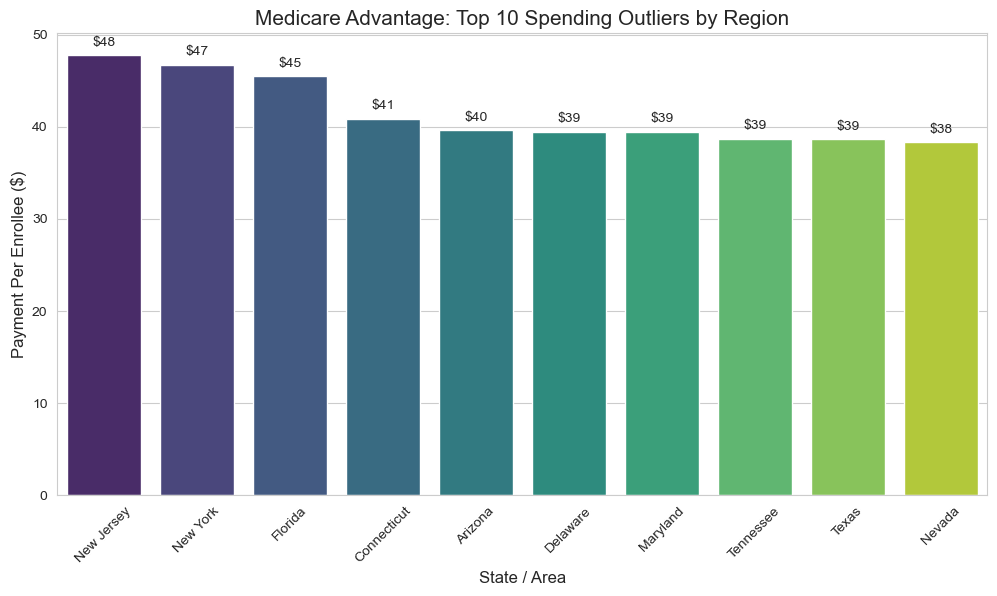

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Clean the Data: Remove empty rows and "Total" summaries
df_clean = df.dropna(subset=['Area of Residence'])
df_clean = df_clean[~df_clean['Area of Residence'].str.contains("Total|Residence", na=False)]

# 2. Identify the "Payment Per Person" column dynamically
# (CMS names are long, so we look for the one containing 'Per Original Medicare')
target_col = [c for c in df_clean.columns if 'Per Original Medicare' in c][0]

# 3. Convert to numeric to ensure we can sort/plot
df_clean[target_col] = pd.to_numeric(df_clean[target_col], errors='coerce')
df_clean = df_clean.dropna(subset=[target_col])

# 4. Get the Top 10 Outliers
top_10 = df_clean.sort_values(by=target_col, ascending=False).head(10)

print("--- Top 10 Areas by Spending Per Person ---")
print(top_10[['Area of Residence', target_col]])

# 5. Create the Visualization
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")
chart = sns.barplot(data=top_10, x='Area of Residence', y=target_col, palette="viridis")

plt.title('Medicare Advantage: Top 10 Spending Outliers by Region', fontsize=15)
plt.ylabel('Payment Per Enrollee ($)', fontsize=12)
plt.xlabel('State / Area', fontsize=12)
plt.xticks(rotation=45)

# Add labels on top of bars
for p in chart.patches:
    chart.annotate(f'${p.get_height():.0f}', 
                   (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha = 'center', va = 'center', 
                   xytext = (0, 9), 
                   textcoords = 'offset points')

plt.show()